In [ ]:
!mkdir -p data/content
!mkdir -p data/style
!mkdir -p outputs
!mkdir -p scripts


In [ ]:
from google.colab import files

# Upload content image(s), place into data/content/
uploaded = files.upload()
for filename in uploaded.keys():
    !mv {filename} data/content/

# Upload style image(s), place into data/style/
uploaded = files.upload()
for filename in uploaded.keys():
    !mv {filename} data/style/


Saving mountain.jpg to mountain.jpg


Saving lynx-rain-princess.jpg to lynx-rain-princess.jpg


In [ ]:
# Create utils.py
%%writefile scripts/utils.py
import tensorflow as tf
import numpy as np
import PIL.Image

def load_img(path_to_img, max_dim=512):
    img = PIL.Image.open(path_to_img)
    img = img.convert('RGB')
    long_dim = max(img.size)
    scale = max_dim / long_dim
    new_size = (round(img.size[0] * scale), round(img.size[1] * scale))
    # Updated from PIL.Image.ANTIALIAS to PIL.Image.Resampling.LANCZOS
    img = img.resize(new_size, PIL.Image.Resampling.LANCZOS)

    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.vgg19.preprocess_input(img)
    return tf.convert_to_tensor(img)

def deprocess_img(processed_img):
    x = processed_img.numpy().reshape((processed_img.shape[1], processed_img.shape[2], 3))
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]
    x = np.clip(x, 0, 255).astype('uint8')
    return x

def gram_matrix(input_tensor):
    channels = int(input_tensor.shape[-1])
    vectorized = tf.reshape(input_tensor, [-1, channels])
    gram = tf.matmul(tf.transpose(vectorized), vectorized)
    gram = gram / tf.cast(tf.shape(vectorized)[0], tf.float32)
    return gram


Writing scripts/utils.py


In [ ]:
%%writefile scripts/style_transfer.py
import tensorflow as tf
from scripts.utils import gram_matrix

# Define style and content layers
content_layers = ['block5_conv2']
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

def vgg_model():
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    outputs = [vgg.get_layer(name).output for name in (style_layers + content_layers)]
    return tf.keras.Model([vgg.input], outputs)

def get_feature_representations(model, content_image, style_image):
    style_outputs = model(style_image)
    content_outputs = model(content_image)

    style_features = [gram_matrix(style_output) for style_output in style_outputs[:num_style_layers]]
    content_features = content_outputs[num_style_layers:]
    return style_features, content_features

def compute_loss(model, init_image, style_features, content_features, style_weight=1e-2, content_weight=1e4):
    outputs = model(init_image)
    style_output_features = outputs[:num_style_layers]
    content_output_features = outputs[num_style_layers:]

    style_loss = 0
    content_loss = 0

    for comb_style, target_style in zip(style_output_features, style_features):
        gram_comb = gram_matrix(comb_style)
        style_loss += tf.reduce_mean(tf.square(gram_comb - target_style))
    style_loss /= num_style_layers

    for comb_content, target_content in zip(content_output_features, content_features):
        content_loss += tf.reduce_mean(tf.square(comb_content - target_content))
    content_loss /= num_content_layers

    total_loss = (style_weight * style_loss) + (content_weight * content_loss)
    return total_loss, style_loss, content_loss

@tf.function
def compute_grads(config):
    with tf.GradientTape() as tape:
        loss, style_loss, content_loss = compute_loss(**config)
    return tape.gradient(loss, config['init_image']), loss, style_loss, content_loss

def run_style_transfer(content_image, style_image, num_iterations=1000, style_weight=1e-2, content_weight=1e4):
    model = vgg_model()
    model.trainable = False

    style_features, content_features = get_feature_representations(model, content_image, style_image)
    init_image = tf.Variable(content_image, dtype=tf.float32)

    optimizer = tf.optimizers.Adam(learning_rate=5.0)

    config = {
        'model': model,
        'init_image': init_image,
        'style_features': style_features,
        'content_features': content_features,
        'style_weight': style_weight,
        'content_weight': content_weight
    }

    best_img = None
    best_loss = float('inf')

    for i in range(num_iterations):
        grads, loss, style_loss, content_loss = compute_grads(config)
        optimizer.apply_gradients([(grads, init_image)])
        clipped = tf.clip_by_value(init_image, -103.939, 255 - 103.939)
        init_image.assign(clipped)

        if loss < best_loss:
            best_loss = loss
            best_img = init_image.numpy()

        if i % 100 == 0:
            print(f'Iteration {i}: Total loss={loss:.4e}, Style loss={style_loss:.4e}, Content loss={content_loss:.4e}')

    return best_img


Writing scripts/style_transfer.py


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Iteration 0: Total loss=5.1766e+08, Style loss=5.1766e+10, Content loss=0.0000e+00
Iteration 100: Total loss=5.8410e+06, Style loss=2.2965e+08, Content loss=3.5445e+02
Iteration 200: Total loss=4.1072e+06, Style loss=1.5506e+08, Content loss=2.5566e+02
Iteration 300: Total loss=3.9942e+06, Style loss=1.7848e+08, Content loss=2.2095e+02
Iteration 400: Total loss=3.0770e+06, Style loss=1.1543e+08, Content loss=1.9228e+02


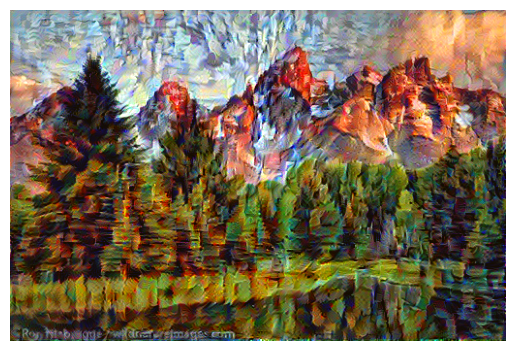

Stylized image saved at outputs/stylized_output.png


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from scripts.utils import load_img, deprocess_img
from scripts.style_transfer import run_style_transfer

def main():
    # Paths to images - update with your own paths or file upload in Colab
    content_path = '/content/data/content/mountain.jpg'
    style_path = '/content/data/style/lynx-rain-princess.jpg'

    content_image = load_img(content_path)
    style_image = load_img(style_path)

    output = run_style_transfer(content_image, style_image, num_iterations=500)
    output_img = deprocess_img(tf.convert_to_tensor(output))

    # Show result
    plt.imshow(output_img)
    plt.axis('off')
    plt.show()

    # Save output
    output_path = 'outputs/stylized_output.png'
    tf.keras.preprocessing.image.save_img(output_path, output_img)
    print(f'Stylized image saved at {output_path}')

if __name__ == '__main__':
    main()
